# Example 3: Risk Model and Survival Analysis

This notebook demonstrates:
- `compute_guan_rank()` — converts survival data into risk scores for model training
- `km_plot()` — Kaplan-Meier survival curves with log-rank test
- `concordance()` — evaluates how well risk scores predict survival

## Background

The risk model predicts patient survival from **program activity** — the mean
quantized activity of regulons within each transcriptional program.

**GuanRank** transforms survival data into scores between 0 and 1:
- Score > 0.5 = high risk (dies sooner)
- Score < 0.5 = low risk (lives longer)

This is used as the target variable for ridge regression since standard
survival models don't work directly as regression targets.

**Kaplan-Meier curves** visualise whether patients above/below the median
risk score have significantly different survival — validated by the log-rank test.

**Concordance index (C-index)** measures overall model performance:
- 0.5 = random (no predictive power)
- 1.0 = perfect prediction
- > 0.6 = clinically meaningful

In [2]:
import numpy as np
import pandas as pd
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold
import sys
sys.path.append(r"D:\School\IITD\General\GBM\gbm_model.ipynb")

from utils import compute_guan_rank, km_plot, concordance

## 1. Create synthetic survival and program activity data

In [3]:
np.random.seed(42)
n_patients  = 100
n_programs  = 16

patient_ids = [f'PATIENT_{i}' for i in range(n_patients)]

# Simulate survival data
# Two groups: high-risk (short survival) and low-risk (long survival)
os_months = np.concatenate([
    np.random.exponential(scale=12, size=50),  # high risk — median ~12 months
    np.random.exponential(scale=36, size=50)   # low risk  — median ~36 months
])
os_status = np.ones(n_patients, dtype=int)     # all events observed

clinical = pd.DataFrame({
    'OS_MONTHS': os_months,
    'OS_STATUS': os_status
}, index=patient_ids)

print(f"Clinical data: {clinical.shape}")
print(f"Median survival: {clinical['OS_MONTHS'].median():.1f} months")
print(clinical.head())

Clinical data: (100, 2)
Median survival: 11.4 months
           OS_MONTHS  OS_STATUS
PATIENT_0   5.631217          1
PATIENT_1  36.121457          1
PATIENT_2  15.800948          1
PATIENT_3  10.955311          1
PATIENT_4   2.035498          1


In [4]:
# Simulate program activity matrix (n_programs x n_patients)
# High-risk patients (0-49) have higher activity in programs 0-7
program_activity = pd.DataFrame(
    np.random.randn(n_programs, n_patients) * 0.1,
    index=range(n_programs),
    columns=patient_ids
)

# Inject signal: high-risk patients have elevated activity in first 8 programs
for prog in range(8):
    program_activity.loc[prog, patient_ids[:50]] += 0.5

print(f"Program activity: {program_activity.shape}  (programs x patients)")

Program activity: (16, 100)  (programs x patients)


## 2. Compute GuanRank scores

`compute_guan_rank(survival_df)` assigns each patient a score between 0 and 1
based on their survival relative to all other patients.

- **Deceased patients**: scored by proportion of patients who survived longer
- **Censored patients**: scored by proportion who died before their censoring time

This handles right-censoring properly — we don't know when censored patients
actually die, so we use what we do know.

In [5]:
guan_scores = compute_guan_rank(clinical)

print(f"GuanRank scores: {len(guan_scores)} patients")
print(f"Range: [{guan_scores.min():.3f}, {guan_scores.max():.3f}]")
print(f"Mean:  {guan_scores.mean():.3f}  (should be ~0.5)")
print(f"High risk (>0.5): {(guan_scores > 0.5).sum()} patients")
print(f"Low risk  (≤0.5): {(guan_scores <= 0.5).sum()} patients")
print(f"\nFirst 5 scores:")
print(guan_scores.head())

GuanRank scores: 100 patients
Range: [0.000, 1.000]
Mean:  0.500  (should be ~0.5)
High risk (>0.5): 50 patients
Low risk  (≤0.5): 50 patients

First 5 scores:
index
PATIENT_0    0.656566
PATIENT_1    0.222222
PATIENT_2    0.404040
PATIENT_3    0.535354
PATIENT_4    0.878788
Name: GuanRank, dtype: float64


## 3. Train ridge regression risk model

We use **ridge regression** with 5-fold cross-validation to predict GuanRank
from program activity. Out-of-fold (OOF) predictions give an unbiased
estimate of model performance on the training cohort.

In [6]:
# Align patients
common_patients = program_activity.columns.intersection(guan_scores.index)
X = program_activity[common_patients].T.values   # (n_patients x n_programs)
y = guan_scores[common_patients].values
patients = np.array(common_patients)

# 5-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_predictions = np.zeros(len(common_patients))

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    ridge = RidgeCV(alphas=np.logspace(-3, 3, 100), cv=5)
    ridge.fit(X[train_idx], y[train_idx])
    oof_predictions[val_idx] = ridge.predict(X[val_idx])
    print(f"Fold {fold+1}/5 done")

# Fit final model on all data
ridge_final = RidgeCV(alphas=np.logspace(-3, 3, 100), cv=5)
ridge_final.fit(X, y)

print(f"\nBest alpha: {ridge_final.alpha_:.4f}")

Fold 1/5 done
Fold 2/5 done
Fold 3/5 done
Fold 4/5 done
Fold 5/5 done

Best alpha: 7.5646


## 4. Evaluate with concordance index

`concordance(risk_scores, survival_df)` computes the C-index.
Internally negates risk scores since higher risk score = shorter survival,
which is the opposite of what `concordance_index` expects by default.

In [8]:
oof_series = pd.Series(oof_predictions, index=patients)

ci = concordance(oof_series, clinical)
print(f"C-index (5-fold CV): {ci:.4f}")
print(f"Interpretation:")
print(f"  0.50 = random (no predictive power)")
print(f"  0.60 = clinically meaningful")
print(f"  1.00 = perfect prediction")

C-index (5-fold CV): 0.5929
Interpretation:
  0.50 = random (no predictive power)
  0.60 = clinically meaningful
  1.00 = perfect prediction


## 5. Kaplan-Meier survival curves

`km_plot(risk_scores, survival_df)` splits patients at the median risk score
and plots survival curves for high vs low risk groups.

The **log-rank test** p-value tells us if the two groups have significantly
different survival — p ≤ 0.05 means the risk model successfully stratifies patients.

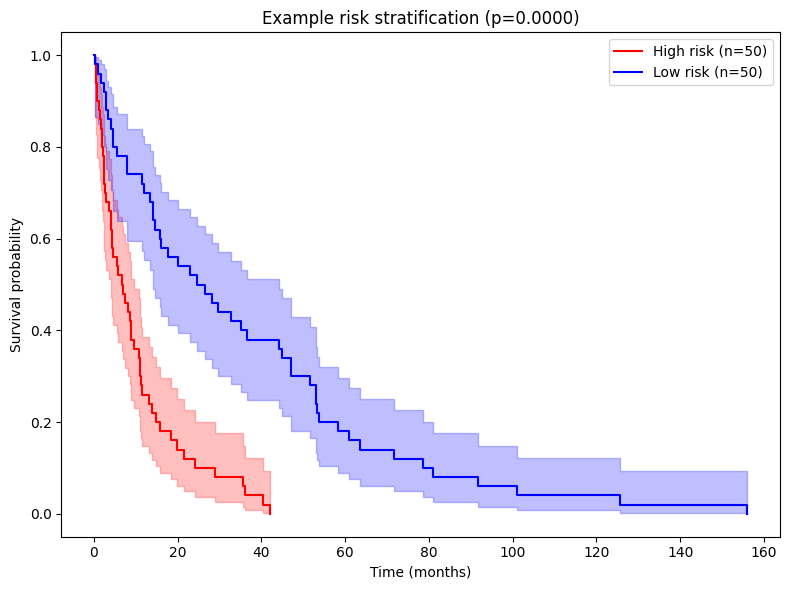

Log-rank p-value: 2.9537e-08

Log-rank p-value: 2.9537e-08
Significant (p<0.05): True


In [9]:
pval = km_plot(
    oof_series,
    clinical,
    title='Example risk stratification'
)

print(f"\nLog-rank p-value: {pval:.4e}")
print(f"Significant (p<0.05): {pval < 0.05}")

## 6. Apply to a validation cohort

In the full pipeline, the model trained on TCGA is applied to
the independent Gravendeel cohort. Here we simulate this.

Validation C-index: 0.6906


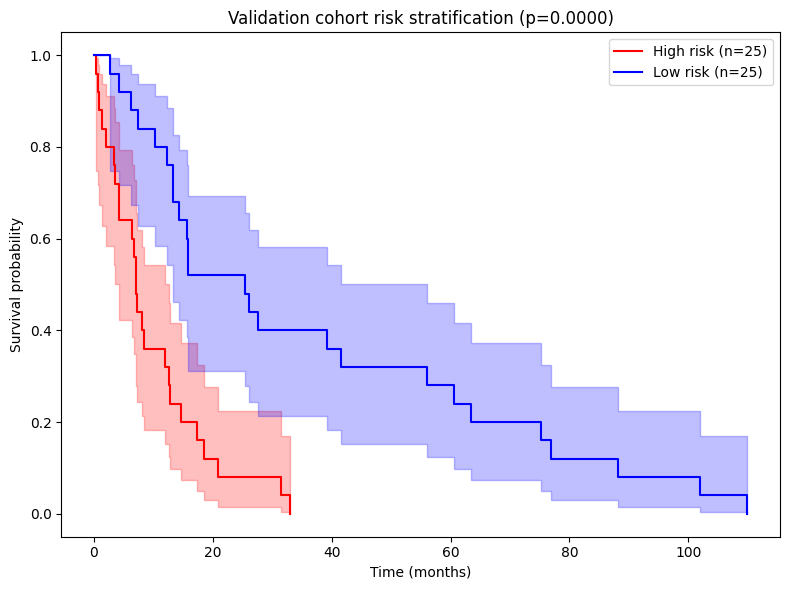

Log-rank p-value: 2.9774e-05


In [10]:
# Simulate a validation cohort (50 patients, same 16 programs)
n_val = 50
val_patient_ids = [f'VAL_PATIENT_{i}' for i in range(n_val)]

val_program_activity = pd.DataFrame(
    np.random.randn(n_programs, n_val) * 0.1,
    index=range(n_programs),
    columns=val_patient_ids
)
# Inject same signal pattern
for prog in range(8):
    val_program_activity.loc[prog, val_patient_ids[:25]] += 0.5

val_clinical = pd.DataFrame({
    'OS_MONTHS': np.concatenate([
        np.random.exponential(scale=12, size=25),
        np.random.exponential(scale=36, size=25)
    ]),
    'OS_STATUS': np.ones(n_val, dtype=int)
}, index=val_patient_ids)

# Apply trained model
X_val          = val_program_activity.T.values
y_pred_val     = ridge_final.predict(X_val)
val_risk_scores = pd.Series(y_pred_val, index=val_patient_ids)

# Evaluate
ci_val = concordance(val_risk_scores, val_clinical)
print(f"Validation C-index: {ci_val:.4f}")

pval_val = km_plot(
    val_risk_scores,
    val_clinical,
    title='Validation cohort risk stratification'
)